In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
### Creating a non linear data features
x = 6 * np.random.rand(100, 1) - 3
y = 0.5 * x**2 + x + 2 + np.random.rand(100, 1)

Text(0, 0.5, 'Y')

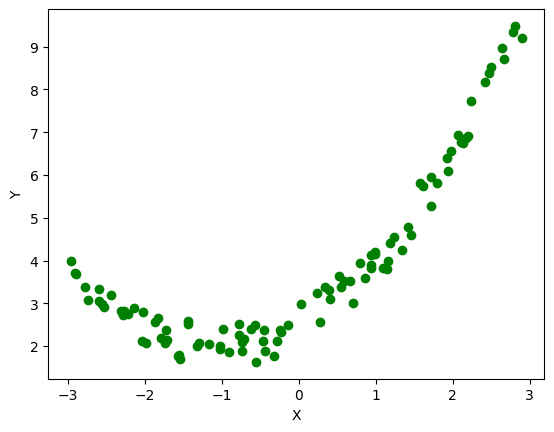

In [4]:
### Plotting of datapoints

plt.scatter(x, y, color = 'g')
plt.xlabel('X')
plt.ylabel('Y')

In [5]:
## train test Split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)



In [6]:
## Implement Simple Linear regression
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(x_train, y_train)

y_pred = lin_reg.predict(x_test)



In [7]:
### Performance metrics

from sklearn.metrics import r2_score

score = r2_score(y_test, y_pred)
print(score)

0.3379335206498981


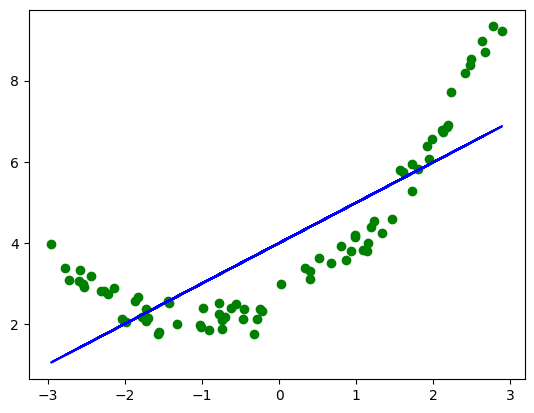

In [ ]:
### Visualization

plt.plot(x_train, lin_reg.predict(x_train), color = 'b')
plt.scatter(x_train, y_train, color = 'g')
plt.show()


In [ ]:
#### You can see that the linear regression model is not able to capture the non linear relationship between x and y. Hence we need to use polynomial regression to capture the non linear relationship.

#### Kitna jyada error hai

In [11]:
### Lets Apply Polynomial Regression

from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree = 3, include_bias = True)

x_poly_train = poly.fit_transform(x_train)
x_poly_test = poly.transform(x_test)

In [12]:
x_poly_test

array([[ 1.00000000e+00,  7.02667527e-01,  4.93741653e-01,
         3.46936226e-01],
       [ 1.00000000e+00,  5.49820659e-01,  3.02302757e-01,
         1.66212301e-01],
       [ 1.00000000e+00, -5.53242351e-01,  3.06077098e-01,
        -1.69334813e-01],
       [ 1.00000000e+00,  2.80674865e+00,  7.87783797e+00,
         2.21111111e+01],
       [ 1.00000000e+00,  9.42300512e-01,  8.87930255e-01,
         8.36697134e-01],
       [ 1.00000000e+00, -2.02404372e+00,  4.09675298e+00,
        -8.29200713e+00],
       [ 1.00000000e+00,  2.78567744e-01,  7.75999878e-02,
         2.16168535e-02],
       [ 1.00000000e+00, -4.43601985e-01,  1.96782721e-01,
        -8.72932057e-02],
       [ 1.00000000e+00, -2.28438756e+00,  5.21842653e+00,
        -1.19209087e+01],
       [ 1.00000000e+00,  1.41694161e+00,  2.00772352e+00,
         2.84482699e+00],
       [ 1.00000000e+00, -1.34428934e-01,  1.80711383e-02,
        -2.42928387e-03],
       [ 1.00000000e+00, -1.17034976e+00,  1.36971857e+00,
      

In [13]:
x_poly_train

array([[ 1.00000000e+00, -1.56148974e+00,  2.43825020e+00,
        -3.80730268e+00],
       [ 1.00000000e+00,  1.15376187e+00,  1.33116645e+00,
         1.53584909e+00],
       [ 1.00000000e+00, -2.27550342e+00,  5.17791583e+00,
        -1.17823652e+01],
       [ 1.00000000e+00, -2.22082606e+00,  4.93206839e+00,
        -1.09532660e+01],
       [ 1.00000000e+00,  2.47368435e+00,  6.11911426e+00,
         1.51367572e+01],
       [ 1.00000000e+00,  1.33712795e+00,  1.78791117e+00,
         2.39066600e+00],
       [ 1.00000000e+00,  6.68081607e-01,  4.46333034e-01,
         2.98186891e-01],
       [ 1.00000000e+00, -7.09386041e-01,  5.03228555e-01,
        -3.56983313e-01],
       [ 1.00000000e+00,  2.78251058e+00,  7.74236511e+00,
         2.15432128e+01],
       [ 1.00000000e+00, -2.43882290e+00,  5.94785713e+00,
        -1.45057702e+01],
       [ 1.00000000e+00,  1.57081588e+00,  2.46746252e+00,
         3.87592930e+00],
       [ 1.00000000e+00,  1.61159238e+00,  2.59723001e+00,
      

In [14]:
from sklearn.linear_model import LinearRegression
lin_reg2 = LinearRegression()
lin_reg2.fit(x_poly_train, y_train)

y_poly_pred = lin_reg2.predict(x_poly_test)

score2 = r2_score(y_test, y_poly_pred)
print(score2)

0.9771434155829537


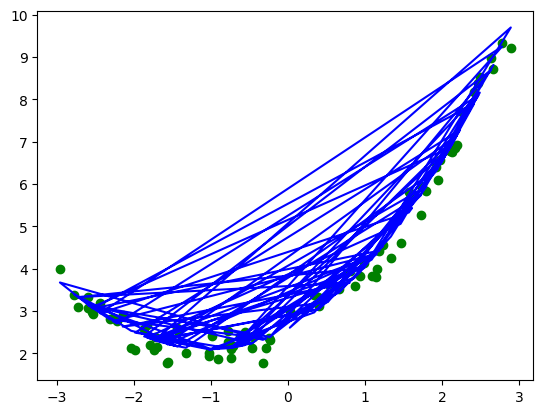

In [16]:
### Plotting the data

plt.plot(x_train, lin_reg2.predict(x_poly_train), color = 'b')
plt.scatter(x_train, y_train, color = 'g')

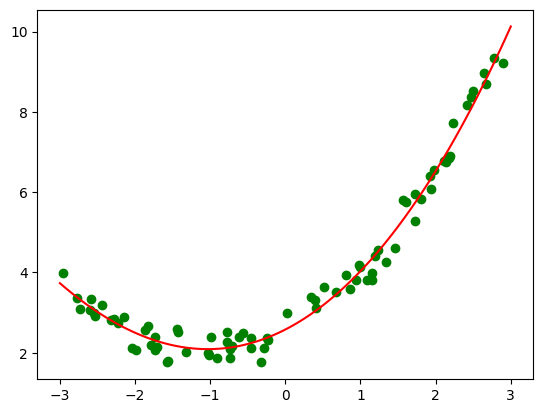

In [17]:
### Predict the new data point

x_new = np.linspace(-3, 3, 100).reshape(100, 1)
x_new_poly = poly.transform(x_new)

y_new_poly = lin_reg2.predict(x_new_poly)

plt.plot(x_new, y_new_poly, color = 'r')
plt.scatter(x_train, y_train, color = 'g')
plt.show()

In [ ]:
#### We should always try to fit the data with the least degree polynomial possible. If we increase the degree of the polynomial, we will be overfitting the data and the model will not generalize well on unseen data. Hence we should always try to fit the data with the least degree polynomial possible.